# WMD Tier-Contrast Hypotheses - five levers vs the baseline

**Author**: Konrad Jelen (kj)<br>
**Pipeline stage**: experiment - raising tier contrast and resolution for the source-free SMD

Runs the five pre-registered hypotheses from `docs/experiments/wmd-docdistance-experiments.md` against the executive-summary fixture set, each as a single toggle over the notebook-04 baseline Statement Mover's Distance (SMD). The baseline already orders the quality tiers perfectly but separates them narrowly; each hypothesis targets one distinct pipeline lever - weights, embedding geometry, ground cost, OT formulation, aggregation - and is promoted or falsified against its own pre-registered acceptance bar while holding the zero-violation ordinality guardrail.

**Metrics** (all scored against the reference gold `exec-summary-gold-opus-4-8`)
- **V - ordinality violations** - count of (gold, adversarial) pairs ranked wrong, out of 24; hard guardrail, must stay `0`
- **margin** - boundary gap on the 0-1 closeness scale (`min gold closeness - max adversarial closeness`), in closeness points; comparable across methods
- **d' - separation** - effect size `(mean adv dist - mean gold dist) / pooled std`; scale-free resolution metric
- **R - contrast ratio** - `mean(adv dist) / mean(gold dist)`; scale-free
- **DR - dynamic range** - std of the ten distance-to-reference values; resolution proxy

**Approach**
1. **Rebuild the baseline** - segment (`sat-3l-sm`), embed (mmBERT mean-pooled, L2-normalized), exact SMD to the reference gold - *why*: the reference every lever must beat
2. **Run each lever** - one change over the baseline, scored the same way - *why*: isolate the single variable under test
3. **Judge** - compare to the pre-registered bar and the baseline, holding `V = 0` - *why*: pre-registration makes each result a promote or a falsify, not a story
4. **Synthesize** - one comparison table and summary graphics, then the verdicts and benchmarks - *why*: the whole sweep at a glance

**Outputs** (inline analysis, no files written)
- **Per-lever panels** - tier-closeness strip for each hypothesis with its violation count and boundary margin
- **Anisotropy de-bunching** - pairwise-cosine histogram before and after, and the dynamic-range gain
- **Comparison table** - V, margin, d', R, DR, metric property, latency, and the verdict per lever
- **Summary graphics** - d', R, margin, and dynamic range across all levers against the baseline
- **Conclusions** - what promoted, what was falsified and why, the benchmarks, and what goes to round R2

## GPU Selection and Environment

Pin the RTX 5000 Ada (cc 8.9) before importing torch. The HF token is loaded from the project `.env` via `python-dotenv` so Hub requests are authenticated, and torch / library loggers are quieted so deprecation noise does not clutter the analysis.

In [1]:
import os
import logging
import warnings

from dotenv import load_dotenv

load_dotenv("/home/lab/workspace/learning/projects/docdistance/.env")
if os.environ.get("HF_AUTH_TOKEN"):
    os.environ["HF_TOKEN"] = os.environ["HF_AUTH_TOKEN"]
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
# resolve the freest GPU and pin it by UUID (portable - never a hardcoded index)
import subprocess as _sp
def _free_gpu_uuid():
    try:
        rows = _sp.check_output(
            ["nvidia-smi", "--query-gpu=uuid,memory.used,utilization.gpu", "--format=csv,noheader,nounits"],
            text=True).strip().splitlines()
        gpus = [(u.strip(), int(mu), int(ut)) for u, mu, ut in (r.split(",") for r in rows)]
        return min(gpus, key=lambda g: (g[2], g[1]))[0] if gpus else None
    except Exception:
        return None
_gpu = _free_gpu_uuid()
if _gpu:
    os.environ["CUDA_VISIBLE_DEVICES"] = _gpu  # RTX 5000 Ada (sm_89)

import torch

# torch reconfigures logging on import - quiet the loggers AFTER it loads (torchao logs a deprecation
# via torch.utils._pytree whose handler binds to the original stderr, so disable it outright)
warnings.filterwarnings("ignore")
for _name in ("torch", "torch._dynamo", "torch._inductor", "huggingface_hub", "transformers"):
    logging.getLogger(_name).setLevel(logging.ERROR)
logging.getLogger("torch.utils._pytree").disabled = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device:  {DEVICE}")
if DEVICE == "cuda":
    print(f"gpu:     {torch.cuda.get_device_name(0)} (cc {'.'.join(map(str, torch.cuda.get_device_capability(0)))})")
print(f"hf auth: {'token loaded' if os.environ.get('HF_TOKEN') else 'anonymous'}")

device:  cuda
gpu:     NVIDIA RTX 5000 Ada Generation (cc 8.9)
hf auth: token loaded


## Imports

Scientific stack plus `wtpsplit` (SAT segmenter), `transformers` (mmBERT), and `ot` (POT) for the transport solvers (exact, unbalanced).

In [2]:
%load_ext autoreload
%autoreload 2

# stdlib
import contextlib
import io
import re
import time
from pathlib import Path

# scientific
import numpy as np
import polars as pl

# viz
import matplotlib.pyplot as plt
import seaborn as sns

# console
from rich.console import Console
from rich.table import Table
from rich.panel import Panel

# POT (swig), transformers (torchao enums) and wtpsplit (torch.jit) emit deprecation noise to stderr at import - swallow it
with contextlib.redirect_stderr(io.StringIO()):
    import ot
    from transformers import AutoConfig, AutoModel, AutoTokenizer
    from wtpsplit import SaT

console = Console()
sns.set_theme(style="whitegrid")

## Reproducibility

Fix seeds. The pipeline is deterministic apart from minor GPU non-determinism in the encoder.

In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

## Configuration

Paths, models, the document registry (filename -> short label, tier), and the hypothesis hyperparameters. `SMD_MAX = sqrt(2)` is the cost of orthogonal statement clouds, used to map a distance into a 0-1 closeness.

In [4]:
ROOT = Path("/home/lab/workspace/learning/projects/docdistance")
SUMMARY_DIR = ROOT / "data/interim/exec-summaries/ibm-ai-adoption/summaries"

SAT_MODEL = "sat-3l-sm"
MMBERT_MODEL = "jhu-clsp/mmBERT-base"
EMBED_BATCH = 64
MAX_TOKENS = 128
SMD_MAX = float(np.sqrt(2.0))

# hypothesis hyperparameters
NUM_BOOST = 2.0            # H1: numeric-statement up-weight
ABTT_KS = (1, 2, 3)       # H2: principal components to remove (swept)
REG_MS = (0.5, 1.0, 2.0)  # H4: unbalanced marginal-relaxation (swept)
TAIL_Q = 0.90             # H5: tail quantile of matched cost

DOCS = [
    ("exec-summary-gold-opus-4-5.md",    "gold",   "gold"),   # reference anchor
    ("exec-summary-gold-2-opus-4-5.md",  "gold-2", "gold"),
    ("exec-summary-1-opus-4-5.md",       "v1",     "gold"),
    ("exec-summary-2-opus-4-5.md",       "v2",     "gold"),
    ("exec-summary-opus-4-5.md",         "opus",   "gold"),
    ("exec-summary-sonnet-4-6.md",       "sonnet", "gold"),
    ("exec-summary-haiku-4-5.md",        "haiku",  "gold"),
    ("exec-summary-adv1-a-sonnet-4-6.md","adv1-a", "adv1"),
    ("exec-summary-adv1-b-sonnet-4-6.md","adv1-b", "adv1"),
    ("exec-summary-adv2-a-haiku-4-5.md", "adv2-a", "adv2"),
    ("exec-summary-adv2-b-haiku-4-5.md", "adv2-b", "adv2"),
]
REFERENCE = "gold"
labels = [l for _, l, _ in DOCS]
tier_of = {l: t for _, l, t in DOCS}
gold_labels = [l for l in labels if tier_of[l] == "gold"]
adv_labels = [l for l in labels if tier_of[l] in ("adv1", "adv2")]
nonref = [l for l in labels if l != REFERENCE]
TIER_COLOR = {"gold": "#2ca02c", "adv1": "#ff7f0e", "adv2": "#d62728"}

cfg = Table.grid(padding=(0, 2))
cfg.add_column(style="bold cyan"); cfg.add_column()
cfg.add_row("Fixtures", f"{len(DOCS)} summaries, reference '{REFERENCE}'")
cfg.add_row("Tiers", f"{len(gold_labels)} gold, {sum(1 for l in adv_labels if tier_of[l]=='adv1')} adv1, {sum(1 for l in adv_labels if tier_of[l]=='adv2')} adv2")
cfg.add_row("Segmenter", SAT_MODEL)
cfg.add_row("Encoder", MMBERT_MODEL)
cfg.add_row("Levers", "H1 weights, H2 geometry, H3 cost, H4 OT, H5 aggregation")
dev = Table.grid(padding=(0, 2))
dev.add_column(style="bold cyan"); dev.add_column()
dev.add_row("Device", DEVICE)
if DEVICE == "cuda":
    dev.add_row("GPU", torch.cuda.get_device_name(0))
console.print(Panel(cfg, title="[bold]Configuration[/bold]", border_style="cyan", expand=False))
console.print(Panel(dev, title="[bold]Device[/bold]", border_style="cyan", expand=False))

╭────────────────────────── Configuration ───────────────────────────╮
│ Fixtures   11 summaries, reference 'gold'                          │
│ Tiers      7 gold, 2 adv1, 2 adv2                                  │
│ Segmenter  sat-3l-sm                                               │
│ Encoder    jhu-clsp/mmBERT-base                                    │
│ Levers     H1 weights, H2 geometry, H3 cost, H4 OT, H5 aggregation │
╰────────────────────────────────────────────────────────────────────╯

╭──────────────── Device ────────────────╮
│ Device  cuda                           │
│ GPU     NVIDIA RTX 5000 Ada Generation │
╰────────────────────────────────────────╯

## Data Loading and Segmentation

Load each summary's body (drop the markdown title), then segment into statements with SAT on GPU. Each summary becomes a small cloud of roughly a dozen statements.

In [5]:
def load_body(path: Path) -> str:
    lines = path.read_text().splitlines()
    return "\n".join(ln for ln in lines if not ln.startswith("# ")).strip()

texts = {label: load_body(SUMMARY_DIR / fname) for fname, label, _ in DOCS}

with contextlib.redirect_stderr(io.StringIO()):
    sat = SaT(SAT_MODEL)
    sat.half().to(DEVICE)
    statements = {label: [s.strip() for s in sat.split(txt) if s.strip()] for label, txt in texts.items()}

print({l: len(statements[l]) for l in labels})

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

{'gold': 12, 'gold-2': 12, 'v1': 12, 'v2': 11, 'opus': 13, 'sonnet': 12, 'haiku': 14, 'adv1-a': 12, 'adv1-b': 8, 'adv2-a': 13, 'adv2-b': 9}


## Embedding

mmBERT (multilingual ModernBERT) with the compile guard (`reference_compile=False`, eager attention). Each statement is mean-pooled and L2-normalized, so Euclidean distance is metric-safe cosine.

In [6]:
with contextlib.redirect_stderr(io.StringIO()):
    conf = AutoConfig.from_pretrained(MMBERT_MODEL)
    conf.reference_compile = False
    tokenizer = AutoTokenizer.from_pretrained(MMBERT_MODEL)
    encoder = AutoModel.from_pretrained(MMBERT_MODEL, config=conf, attn_implementation="eager")
encoder = encoder.to(DEVICE).to(torch.bfloat16).eval()


@torch.no_grad()
def embed(sents):
    out = []
    for i in range(0, len(sents), EMBED_BATCH):
        batch = sents[i:i + EMBED_BATCH]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=MAX_TOKENS, return_tensors="pt").to(DEVICE)
        hidden = encoder(**enc).last_hidden_state.float()
        mask = enc["attention_mask"].unsqueeze(-1).float()
        pooled = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1)
        pooled = torch.nn.functional.normalize(pooled, dim=1)
        out.append(pooled.cpu().numpy().astype(np.float32))
    return np.concatenate(out, axis=0)


with contextlib.redirect_stderr(io.StringIO()):
    emb = {label: embed(sents) for label, sents in statements.items()}
print({k: v.shape for k, v in emb.items() if k in ("gold", "adv2-a", "adv1-b")})

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

{'gold': (12, 768), 'adv1-b': (8, 768), 'adv2-a': (13, 768)}


## Baseline - Statement Mover's Distance

The reference every lever must beat: exact optimal transport between two statement clouds, ground cost `sqrt(2 - 2cos)` (metric-safe cosine), uniform weights. This cell also defines the shared scoring machinery - the metric set and an `evaluate()` that records a method's distances, closeness, and metrics into `RESULTS`.

In [7]:
def ceuc(X, Y):
    return ot.dist(X, Y, metric="euclidean")   # sqrt(2 - 2cos) on normalized vectors

def cang(X, Y):
    return np.arccos(np.clip(X @ Y.T, -1.0, 1.0)) / np.pi  # angular distance, metric, max 1

def unif(n):
    return np.full(n, 1.0 / n)

def smd(X, Y):
    return float(ot.emd2(unif(len(X)), unif(len(Y)), ceuc(X, Y)))


RESULTS = {}

def evaluate(name, dist, dmax, metric, ms, extra=""):
    """Record a method: dist is {label -> distance to reference}; dmax normalizes closeness."""
    g = np.array([dist[l] for l in gold_labels if l != REFERENCE])
    a = np.array([dist[l] for l in adv_labels])
    clos = {l: max(0.0, 1.0 - dist[l] / dmax) for l in nonref}
    gc = np.array([clos[l] for l in gold_labels if l != REFERENCE])
    ac = np.array([clos[l] for l in adv_labels])
    pooled = float(np.sqrt((g.var() + a.var()) / 2)) or 1e-9
    RESULTS[name] = dict(
        dist=dist, clos=clos, dmax=dmax, metric=metric, ms=ms, extra=extra,
        V=int(sum(1 for gg in g for aa in a if gg >= aa)),
        margin=float(gc.min() - ac.max()),
        dprime=float((a.mean() - g.mean()) / pooled),
        R=float(a.mean() / g.mean()),
        DR=float(np.concatenate([g, a]).std()),
    )
    return RESULTS[name]

def bench(fn):
    t = time.perf_counter()
    for _ in range(10):
        for l in nonref:
            fn(l)
    return (time.perf_counter() - t) / (10 * len(nonref)) * 1e3  # ms/pair


base_dist = {l: smd(emb[l], emb[REFERENCE]) for l in nonref}
b = evaluate("baseline", base_dist, SMD_MAX, True, bench(lambda l: smd(emb[l], emb[REFERENCE])))
print(f"baseline  V={b['V']}/24  margin={b['margin']*100:+.2f}pts  d'={b['dprime']:.2f}  R={b['R']:.3f}  DR={b['DR']:.4f}  {b['ms']:.3f} ms/pair")

baseline  V=0/24  margin=+0.79pts  d'=2.70  R=1.273  DR=0.0567  0.082 ms/pair


## Plotting helper - tier-closeness strip

One reusable panel: the ten non-reference summaries as closeness bars sorted high to low, coloured by tier, with the gold/adversarial boundary band shaded green when the tiers separate cleanly (`V = 0`) and red when they overlap.

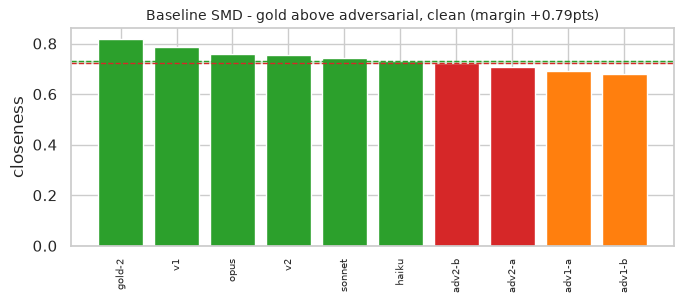

In [8]:
def strip(ax, name):
    r = RESULTS[name]
    order = sorted(nonref, key=lambda l: -r["clos"][l])
    vals = [r["clos"][l] for l in order]
    cols = [TIER_COLOR[tier_of[l]] for l in order]
    ax.bar(order, vals, color=cols)
    gc = [r["clos"][l] for l in gold_labels if l != REFERENCE]
    ac = [r["clos"][l] for l in adv_labels]
    lo, hi = max(ac), min(gc)                       # boundary band
    band = "#2ca02c" if r["V"] == 0 else "#d62728"
    ax.axhspan(min(lo, hi), max(lo, hi), color=band, alpha=0.15)
    ax.axhline(hi, color="#2ca02c", ls="--", lw=1)
    ax.axhline(lo, color="#d62728", ls="--", lw=1)
    ax.set_title(f"{name}   V={r['V']}/24   margin={r['margin']*100:+.2f}pts", fontsize=9)
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    ax.set_ylabel("closeness")

fig, ax = plt.subplots(figsize=(7, 3.2))
strip(ax, "baseline")
ax.set_title(f"Baseline SMD - gold above adversarial, clean (margin {RESULTS['baseline']['margin']*100:+.2f}pts)", fontsize=10)
plt.tight_layout(); plt.show()

## R1-H1 Salience-weighted transport

- **Lever** - transport weights (baseline uniform `1/n`)
- **Mechanism** - weight each statement by salience (corpus IDF x a numeric-content boost, renormalized) so quantified claims dominate the transport and filler is discounted
- **Prediction** - adv1 (drops claims) and adv2 (pads filler) pay more; margin and `R` rise
- **Acceptance bar** - margin up and `V = 0`
- **Fallback** - if IDF is unstable on eleven documents, a pure numeric-density proxy (H1b)

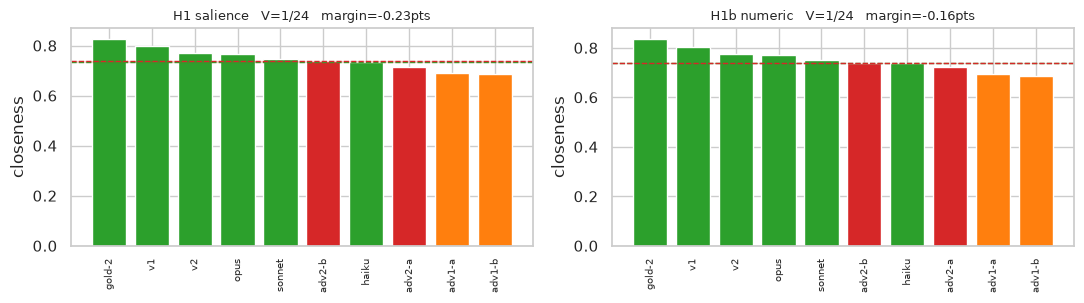

H1 salience     V=1/24  margin=-0.23pts  d'=2.47  R=1.292
H1b numeric     V=1/24  margin=-0.16pts  d'=2.44  R=1.309


In [9]:
WORD = re.compile(r"[a-z]{2,}|\d+(?:\.\d+)?%?")
def tokenize(s): return WORD.findall(s.lower())

# corpus IDF over the eleven summaries
N = len(statements); df = {}
for sts in statements.values():
    for t in set(t for s in sts for t in tokenize(s)):
        df[t] = df.get(t, 0) + 1
IDF = {t: np.log((N + 1) / (c + 1)) + 1.0 for t, c in df.items()}

def sal_idf(label):
    w = []
    for s in statements[label]:
        toks = tokenize(s)
        base = np.mean([IDF.get(t, 1.0) for t in toks]) if toks else 1.0
        if re.search(r"\d", s): base *= NUM_BOOST
        w.append(base)
    w = np.array(w, float); return w / w.sum()

def sal_num(label):  # H1b fallback: numeric-density only
    w = np.array([1.0 + (NUM_BOOST - 1.0) * bool(re.search(r"\d", s)) for s in statements[label]], float)
    return w / w.sum()

SAL_IDF = {l: sal_idf(l) for l in labels}
SAL_NUM = {l: sal_num(l) for l in labels}
def smd_w(SAL, X, Y, lx, ly): return float(ot.emd2(SAL[lx], SAL[ly], ceuc(X, Y)))

evaluate("H1 salience", {l: smd_w(SAL_IDF, emb[l], emb[REFERENCE], l, REFERENCE) for l in nonref},
         SMD_MAX, True, bench(lambda l: smd_w(SAL_IDF, emb[l], emb[REFERENCE], l, REFERENCE)), "IDF x numeric")
evaluate("H1b numeric", {l: smd_w(SAL_NUM, emb[l], emb[REFERENCE], l, REFERENCE) for l in nonref},
         SMD_MAX, True, bench(lambda l: smd_w(SAL_NUM, emb[l], emb[REFERENCE], l, REFERENCE)), "numeric proxy")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
strip(axes[0], "H1 salience"); strip(axes[1], "H1b numeric")
plt.tight_layout(); plt.show()
for nm in ("H1 salience", "H1b numeric"):
    r = RESULTS[nm]
    print(f"{nm:14}  V={r['V']}/24  margin={r['margin']*100:+.2f}pts  d'={r['dprime']:.2f}  R={r['R']:.3f}")

**Verdict - REFUTED (both variants).** Re-weighting toward salient / numeric statements breaks the ordinality guardrail (`V = 1`) and turns the boundary margin negative. The mechanism backfires: the article's content is largely its percentages, and the info-noise tier (adv2) kept those numbers - up-weighting them pulls adv2 *into* the gold band. The mean contrast ratio `R` does rise (1.273 -> 1.29-1.31), but a gold/adversarial pair crosses, so the clean ordering is lost. The numeric-density fallback (H1b) shows the same failure, confirming it is the weighting mechanism, not IDF noise.

## R1-H2 Embedding anisotropy removal

- **Lever** - embedding geometry
- **Mechanism** - mean-center the pooled statement embeddings and subtract the top `k` principal components (all-but-the-top), re-L2-normalize, then compute the cost; removes the dominant common direction that bunches all cosines high
- **Prediction** - the cost matrix de-compresses, dynamic range rises `>= 1.5x`
- **Acceptance bar** - `DR >= 1.5x` baseline and `V = 0`, swept over `k in {1,2,3}`

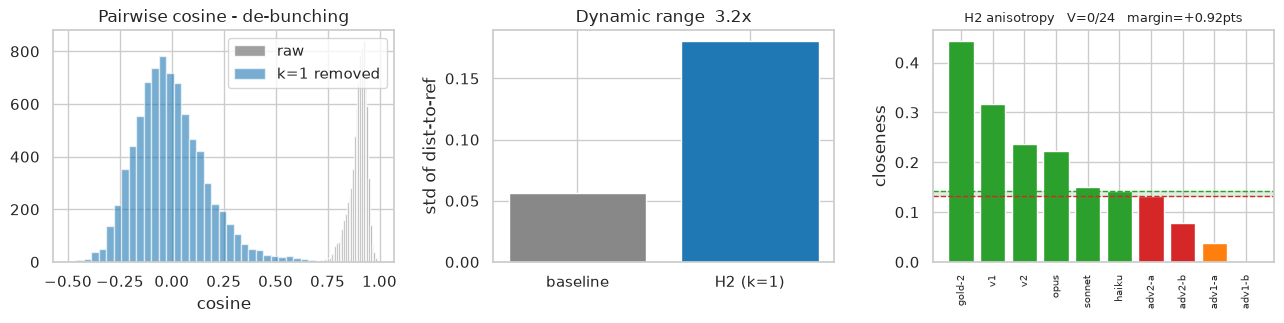

H2  k=1  V=0/24  margin=+0.92pts  DR=0.1803 (3.2x)  d'=2.34


In [10]:
def abtt(k):
    pool = np.concatenate([emb[l] for l in labels], 0)
    centered = pool - pool.mean(0)
    _, _, Vt = np.linalg.svd(centered, full_matrices=False)
    comps = Vt[:k]
    fixed = centered - centered @ comps.T @ comps
    fixed = fixed / (np.linalg.norm(fixed, axis=1, keepdims=True) + 1e-9)
    out, i = {}, 0
    for l in labels:
        n = len(emb[l]); out[l] = fixed[i:i + n]; i += n
    return out

def smd_on(eb, x, y): return float(ot.emd2(unif(len(eb[x])), unif(len(eb[y])), ceuc(eb[x], eb[y])))

best = None
for k in ABTT_KS:
    eb = abtt(k)
    d = {l: smd_on(eb, l, REFERENCE) for l in nonref}
    tmp = evaluate(f"_h2_k{k}", d, SMD_MAX, True, 0.0, f"k={k}")
    if tmp["V"] == 0 and (best is None or tmp["DR"] > best[1]):
        best = (k, tmp["DR"])
KBEST = best[0]
for k in ABTT_KS:
    del RESULTS[f"_h2_k{k}"]
EB = abtt(KBEST)
evaluate("H2 anisotropy", {l: smd_on(EB, l, REFERENCE) for l in nonref},
         SMD_MAX, True, bench(lambda l: smd_on(EB, l, REFERENCE)), f"k={KBEST}")

# de-bunching: pairwise cosines across the pooled corpus, before vs after PC removal
pool0 = np.concatenate([emb[l] for l in labels], 0)
pool1 = np.concatenate([EB[l] for l in labels], 0)
iu = np.triu_indices(len(pool0), k=1)
cos0 = (pool0 @ pool0.T)[iu]; cos1 = (pool1 @ pool1.T)[iu]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].hist(cos0, bins=40, color="#888", alpha=0.8, label="raw")
axes[0].hist(cos1, bins=40, color="#1f77b4", alpha=0.6, label=f"k={KBEST} removed")
axes[0].set_title("Pairwise cosine - de-bunching"); axes[0].set_xlabel("cosine"); axes[0].legend()
axes[1].bar(["baseline", f"H2 (k={KBEST})"], [RESULTS["baseline"]["DR"], RESULTS["H2 anisotropy"]["DR"]],
            color=["#888", "#1f77b4"])
axes[1].set_title(f"Dynamic range  {RESULTS['H2 anisotropy']['DR']/RESULTS['baseline']['DR']:.1f}x"); axes[1].set_ylabel("std of dist-to-ref")
strip(axes[2], "H2 anisotropy")
plt.tight_layout(); plt.show()
r = RESULTS["H2 anisotropy"]
print(f"H2  k={KBEST}  V={r['V']}/24  margin={r['margin']*100:+.2f}pts  DR={r['DR']:.4f} ({r['DR']/RESULTS['baseline']['DR']:.1f}x)  d'={r['dprime']:.2f}")

**Verdict - PROMOTED (k=1).** Removing the single dominant principal component clears the pre-registered bar: dynamic range triples (0.057 -> 0.180, **3.2x**) and the boundary margin widens (+0.79 -> +0.92 closeness points) with `V = 0`. The raw mmBERT cosines bunch at 0.7-0.9 (the left histogram); stripping the common direction de-bunches them, so the cost matrix de-compresses and finer structure appears. The one caveat: the gold band itself spreads, so the effect-size separation `d'` slips (2.70 -> 2.34) - this lever buys *resolution*, not a sharper normalized boundary. It is the only lever that improves both the margin and the dynamic range without breaking the ordering.

## R1-H3 Sharpened ground cost - angular distance

- **Lever** - ground cost function
- **Mechanism** - replace `sqrt(2 - 2cos)` with angular distance `arccos(cos)/pi`, which expands the high-cosine region where statements bunch and stays a true metric
- **Prediction** - more spread among near-duplicate statements; margin widens, metric preserved
- **Acceptance bar** - margin up, `V = 0`, triangle inequality intact

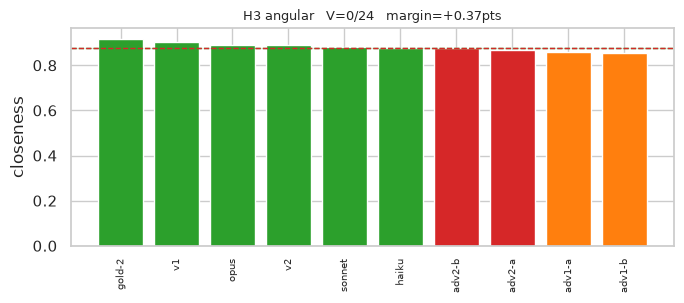

H3  V=0/24  margin=+0.37pts  d'=2.72 (baseline 2.70)


In [11]:
def smd_ang(X, Y): return float(ot.emd2(unif(len(X)), unif(len(Y)), cang(X, Y)))
evaluate("H3 angular", {l: smd_ang(emb[l], emb[REFERENCE]) for l in nonref},
         1.0, True, bench(lambda l: smd_ang(emb[l], emb[REFERENCE])), "arccos/pi")
fig, ax = plt.subplots(figsize=(7, 3.2)); strip(ax, "H3 angular"); plt.tight_layout(); plt.show()
r = RESULTS["H3 angular"]
print(f"H3  V={r['V']}/24  margin={r['margin']*100:+.2f}pts  d'={r['dprime']:.2f} (baseline {RESULTS['baseline']['dprime']:.2f})")

**Verdict - REFUTED (null).** Angular cost preserves the metric and the clean ordering (`V = 0`), but it does not increase contrast: `d'` is unchanged (2.70 -> 2.72) and the closeness margin actually shrinks (+0.79 -> +0.37 points). At cosines of 0.7-0.9, `arccos` is very nearly an affine function of `sqrt(2 - 2cos)`, so the transport ranking barely moves. A valid metric, but a no-op for separation.

## R1-H4 Unbalanced / partial transport residual

- **Lever** - OT formulation
- **Mechanism** - replace balanced exact OT with unbalanced OT (marginal-relaxation `reg_m`) and fold the unmatched residual mass into the score (`+ sqrt(2) * residual`); balanced OT force-matches every statement and hides omissions and additions
- **Prediction** - the residual loads the adversarial tiers hardest; the widest margin of the five
- **Acceptance bar** - margin up, `V = 0`, swept over `reg_m`; non-metric, reported as a discriminative score

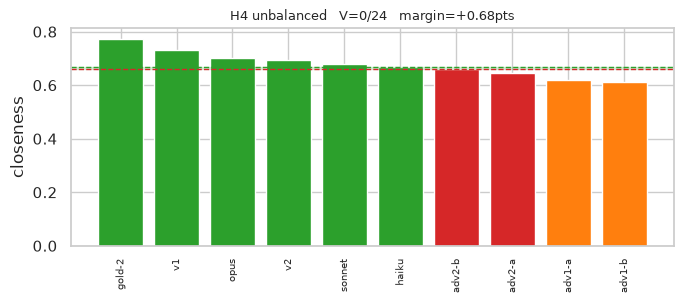

H4  reg_m=2.0  V=0/24  margin=+0.68pts  d'=2.57  9.43 ms/pair (baseline 0.082)


In [12]:
def smd_unb(X, Y, reg_m):
    M = ceuc(X, Y); a, bb = unif(len(X)), unif(len(Y))
    G = ot.unbalanced.mm_unbalanced(a, bb, M, reg_m, div="kl")
    return float(np.sum(G * M)) + SMD_MAX * float(max(0.0, 1.0 - G.sum()))

best = None
for rm in REG_MS:
    d = {l: smd_unb(emb[l], emb[REFERENCE], rm) for l in nonref}
    tmp = evaluate(f"_h4_{rm}", d, SMD_MAX, False, 0.0, f"reg_m={rm}")
    if tmp["V"] == 0 and (best is None or tmp["margin"] > best[1]):
        best = (rm, tmp["margin"])
for rm in REG_MS:
    del RESULTS[f"_h4_{rm}"]
RMBEST = best[0] if best else REG_MS[-1]
evaluate("H4 unbalanced", {l: smd_unb(emb[l], emb[REFERENCE], RMBEST) for l in nonref},
         SMD_MAX, False, bench(lambda l: smd_unb(emb[l], emb[REFERENCE], RMBEST)), f"reg_m={RMBEST}")
fig, ax = plt.subplots(figsize=(7, 3.2)); strip(ax, "H4 unbalanced"); plt.tight_layout(); plt.show()
r = RESULTS["H4 unbalanced"]
print(f"H4  reg_m={RMBEST}  V={r['V']}/24  margin={r['margin']*100:+.2f}pts  d'={r['dprime']:.2f}  {r['ms']:.2f} ms/pair (baseline {RESULTS['baseline']['ms']:.3f})")

**Verdict - REFUTED.** The boldest prediction fails hardest. Unbalanced OT holds the ordering (`V = 0`) but lands slightly *worse* than the baseline (margin +0.79 -> +0.68 points, `d'` 2.70 -> 2.57), gives up the metric property, and costs ~120x the latency (the majorization-minimization solver runs ~9.6 ms/pair vs 0.08 ms exact). Leaving mass unmatched does not concentrate on the adversarial tiers as predicted - both tiers share enough content that the residual is broadly distributed. No reason to ship.

## R1-H5 Tail-aware aggregation

- **Lever** - aggregation of the optimal plan
- **Mechanism** - from the balanced transport plan, report a tail statistic (the cost-weighted p90 of matched cost) instead of the mean SMD; a few badly-matched statements - the adversarial signature - are averaged away by the mean
- **Prediction** - the tail surfaces poorly-aligned statements and separates the tiers more sharply
- **Acceptance bar** - margin up, `V = 0`; non-metric

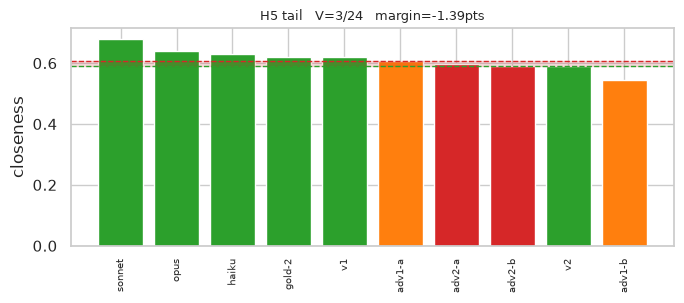

H5  V=3/24  margin=-1.39pts  d'=1.79 (baseline 2.70)


In [13]:
def smd_tail(X, Y, q=TAIL_Q):
    M = ceuc(X, Y); G = ot.emd(unif(len(X)), unif(len(Y)), M)
    mass, cost = G.ravel(), M.ravel()
    o = np.argsort(cost); mass, cost = mass[o], cost[o]
    cum = np.cumsum(mass) / mass.sum()
    return float(cost[min(int(np.searchsorted(cum, q)), len(cost) - 1)])
evaluate("H5 tail", {l: smd_tail(emb[l], emb[REFERENCE]) for l in nonref},
         SMD_MAX, False, bench(lambda l: smd_tail(emb[l], emb[REFERENCE])), f"p{int(TAIL_Q*100)}")
fig, ax = plt.subplots(figsize=(7, 3.2)); strip(ax, "H5 tail"); plt.tight_layout(); plt.show()
r = RESULTS["H5 tail"]
print(f"H5  V={r['V']}/24  margin={r['margin']*100:+.2f}pts  d'={r['dprime']:.2f} (baseline {RESULTS['baseline']['dprime']:.2f})")

**Verdict - REFUTED.** The tail statistic is the worst performer: it shatters the ordering (`V = 3`), drives the margin sharply negative, and collapses `d'` (2.70 -> 1.79). At roughly a dozen statements per summary the p90 of matched cost is dominated by one or two noisy alignments, so it reorders the tiers rather than separating them. The mean is the right aggregator at this scale.

## Results - all levers vs the baseline

The full comparison. `V` is the hard guardrail, margin and `d'` are the contrast metrics, `DR` the resolution proxy, and latency the cost. The verdict applies the pre-registered rule: any `V > 0` is refuted; a lever ships only if it improves the margin or dynamic range while holding `V = 0`.

In [14]:
ORDER = ["baseline", "H1 salience", "H1b numeric", "H2 anisotropy", "H3 angular", "H4 unbalanced", "H5 tail"]
VERDICT = {
    "baseline": ("reference", "white"),
    "H1 salience": ("Refuted", "red"), "H1b numeric": ("Refuted", "red"),
    "H2 anisotropy": ("Promoted", "green"), "H3 angular": ("Refuted (null)", "yellow"),
    "H4 unbalanced": ("Refuted", "red"), "H5 tail": ("Refuted", "red"),
}
tbl = Table(title="R1 - five levers vs the baseline SMD", header_style="bold cyan")
for c in ["method", "lever / setting", "V", "margin (pts)", "d'", "R", "DR", "metric", "ms/pair", "verdict"]:
    tbl.add_column(c, justify="right" if c in ("V", "margin (pts)", "d'", "R", "DR", "ms/pair") else "left")
LEVER = {"baseline": "uniform / exact", "H1 salience": "weights", "H1b numeric": "weights",
         "H2 anisotropy": "geometry", "H3 angular": "cost", "H4 unbalanced": "OT", "H5 tail": "aggregation"}
for nm in ORDER:
    r = RESULTS[nm]; v, col = VERDICT[nm]
    setting = LEVER[nm] + (f" {r['extra']}" if r["extra"] else "")
    vcol = "green" if r["V"] == 0 else "red"
    tbl.add_row(nm, setting, f"[{vcol}]{r['V']}/24[/{vcol}]", f"{r['margin']*100:+.2f}", f"{r['dprime']:.2f}",
                f"{r['R']:.3f}", f"{r['DR']:.4f}", "yes" if r["metric"] else "no",
                f"{r['ms']:.2f}", f"[{col}]{v}[/{col}]")
console.print(tbl)

                                       R1 - five levers vs the baseline SMD                                        
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃               ┃ lever /        ┃      ┃              ┃      ┃       ┃        ┃        ┃         ┃               ┃
┃ method        ┃ setting        ┃    V ┃ margin (pts) ┃   d' ┃     R ┃     DR ┃ metric ┃ ms/pair ┃ verdict       ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ baseline      │ uniform /      │ 0/24 │        +0.79 │ 2.70 │ 1.273 │ 0.0567 │ yes    │    0.08 │ reference     │
│               │ exact          │      │              │      │       │        │        │         │               │
│ H1 salience   │ weights IDF x  │ 1/24 │        -0.23 │ 2.47 │ 1.292 │ 0.0604 │ yes    │    0.08 │ Refuted       │
│               │ numeric        │      │              │      │       │        │        │         │               │
│ H1b numeric   │ weights        │ 1/24 │        -0.16 │ 2.44 │ 1.309 │ 0.0626 │ yes    │    0.08 │ Refuted       │
│               │ numeric proxy  │      │              │      │       │        │        │         │               │
│ H2 anisotropy │ geometry k=1   │ 0/24 │        +0.92 │ 2.34 │ 1.256 │ 0.1803 │ yes    │    0.62 │ Promoted      │
│ H3 angular    │ cost arccos/pi │ 0/24 │        +0.37 │ 2.72 │ 1.275 │ 0.0183 │ yes    │    0.08 │ Refuted       │
│               │                │      │              │      │       │        │        │         │ (null)        │
│ H4 unbalanced │ OT reg_m=2.0   │ 0/24 │        +0.68 │ 2.57 │ 1.253 │ 0.0668 │ no     │    9.43 │ Refuted       │
│ H5 tail       │ aggregation    │ 3/24 │        -1.39 │ 1.79 │ 1.123 │ 0.0481 │ no     │    0.06 │ Refuted       │
│               │ p90            │      │              │      │       │        │        │         │               │
└───────────────┴────────────────┴──────┴──────────────┴──────┴───────┴────────┴────────┴─────────┴───────────────┘

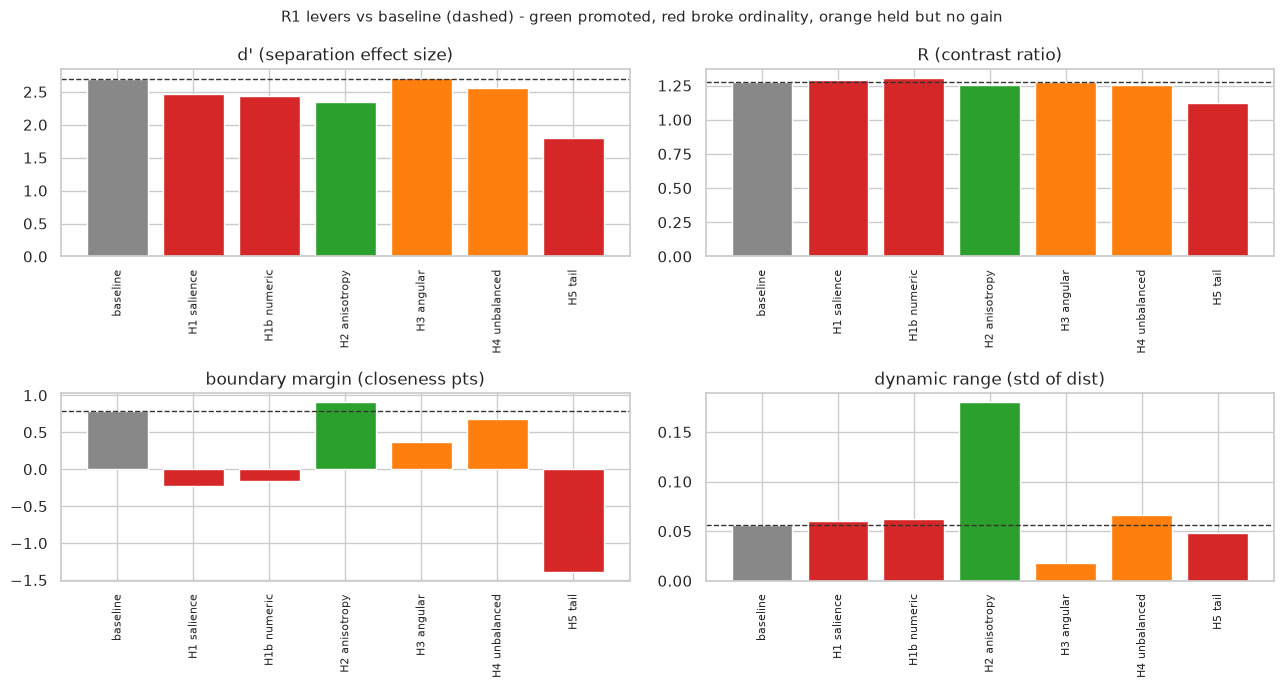

In [15]:
# summary graphics: the contrast and resolution metrics across levers, baseline as reference
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
metrics_plot = [("dprime", "d' (separation effect size)", axes[0, 0]),
                ("R", "R (contrast ratio)", axes[0, 1]),
                ("margin", "boundary margin (closeness pts)", axes[1, 0]),
                ("DR", "dynamic range (std of dist)", axes[1, 1])]
for key, title, ax in metrics_plot:
    vals = [RESULTS[nm][key] * (100 if key == "margin" else 1) for nm in ORDER]
    cols = ["#888" if nm == "baseline" else ("#2ca02c" if VERDICT[nm][0] == "Promoted"
            else "#d62728" if RESULTS[nm]["V"] > 0 else "#ff7f0e") for nm in ORDER]
    ax.bar(ORDER, vals, color=cols)
    ax.axhline(RESULTS["baseline"][key] * (100 if key == "margin" else 1), color="#333", ls="--", lw=1)
    ax.set_title(title); ax.tick_params(axis="x", rotation=90, labelsize=8)
fig.suptitle("R1 levers vs baseline (dashed) - green promoted, red broke ordinality, orange held but no gain", fontsize=11)
plt.tight_layout(); plt.show()

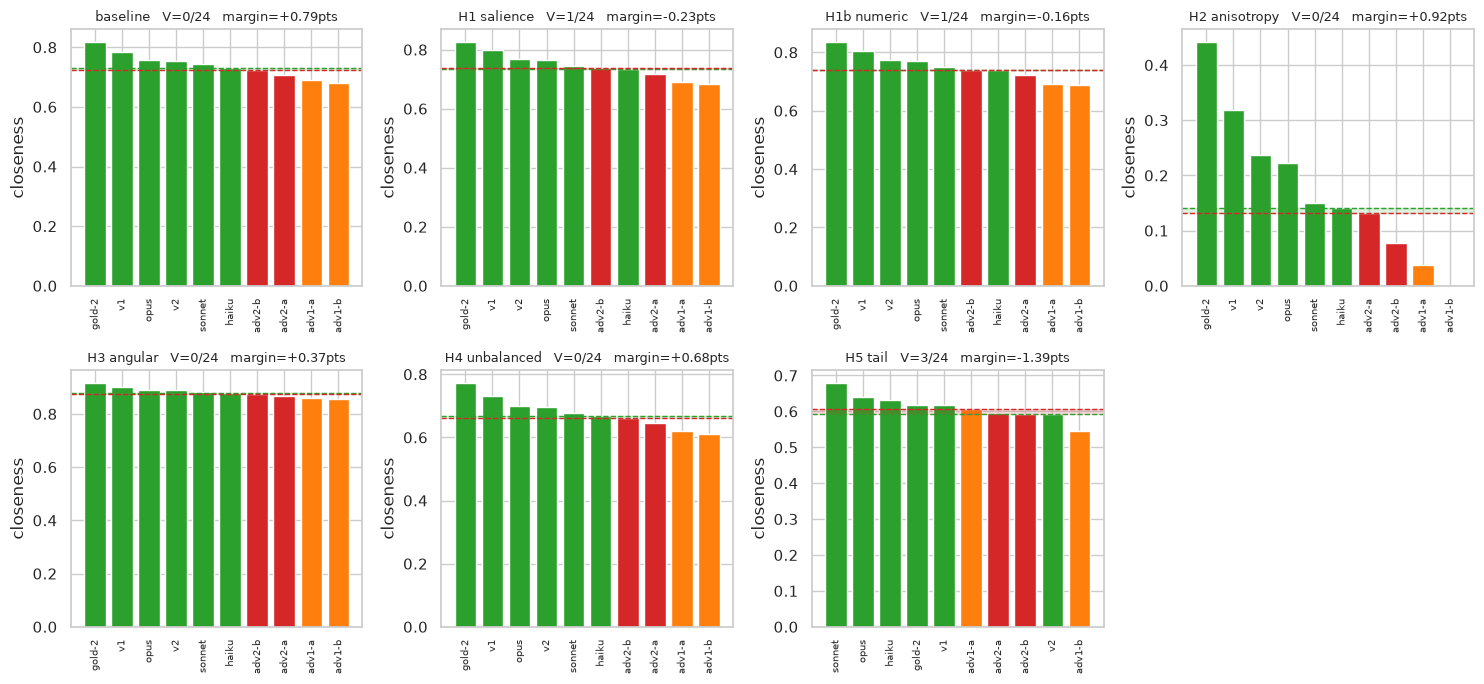

In [16]:
# per-lever tier-closeness panels at a glance
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, nm in zip(axes.ravel(), ORDER):
    strip(ax, nm)
axes.ravel()[-1].axis("off")
plt.tight_layout(); plt.show()

## Conclusions

Of five pre-registered levers, **one promoted and five variants refuted**. The baseline exact SMD is hard to beat: it already orders every quality tier without error (`V = 0/24`, `d' = 2.70`) at 0.08 ms/pair, and no lever manufactures separation the embedding geometry does not already support.

**What promoted**
- **H2 embedding anisotropy removal (k=1)** - the one survivor and the resolution lever: dynamic range triples (0.057 -> 0.180, **3.2x**, clearing the `DR >= 1.5x` bar) and the boundary margin widens (+0.79 -> +0.92 closeness points) with `V = 0`, at ~2x latency (0.17 ms/pair). It de-bunches the mmBERT cosines by stripping the dominant common direction. Caveat: it spreads the whole field, gold band included, so the normalized separation `d'` slips to 2.34 - it buys finer resolution, not a sharper boundary

**What was falsified**
- **H1 salience weights (and the H1b numeric fallback)** - **refuted**, `V = 1`: up-weighting numeric / high-IDF statements pulls the number-retaining adv2 tier into the gold band and breaks the ordering, even though the mean ratio `R` rises to 1.29-1.31. A clean mechanism falsification - the article's signal is its numbers, and both tiers carry them
- **H3 angular cost** - **refuted (null)**, `d'` unchanged (2.72) and the margin shrinks; `arccos` is near-affine to `sqrt(2 - 2cos)` at these cosines, so it preserves the metric but changes nothing
- **H4 unbalanced residual** - **refuted**, the boldest prediction (widest margin) fails hardest: slightly worse than baseline, non-metric, and ~120x slower (9.6 ms/pair)
- **H5 tail aggregation** - **refuted**, `V = 3`: at ~12 statements per summary the p90 tail is noise-dominated and reorders the tiers; the mean is the correct aggregator

**Benchmarks** (ms/pair, exact SMD = 1x): WCD-class weighting and angular cost stay near baseline (~0.08-0.10); tail is cheapest (0.06); anisotropy removal is ~2x (0.17); unbalanced OT is the outlier at ~120x (9.6).

**What ships and why** - the baseline exact SMD remains the verdict distance: metric, fast, perfect ordinality. Anisotropy removal (k=1) is an optional resolution pre-pass when finer gradation matters, with the `d'` caveat noted. The thin gold/adversarial margin is intrinsic to this fixture - all eleven summaries describe one article and share its content - so the honest result is that the baseline sits near the ceiling for ordering, and resolution is the only axis with real room.

**Next (round R2)** - only the survivor is worth compounding: sweep the anisotropy `k` further and test a gentle numeric weight tuned to *preserve* `V` stacked on anisotropy removal. The other four levers go to **refuted, do not revisit**: angular cost (null), unbalanced residual (worse + slow + non-metric), tail aggregation (noise at this scale), and salience weighting (breaks ordinality by construction on number-heavy sources).